# Notebook for constructing age models for the North Shore Volcanics Southwest Sequence

In [16]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## North Shore Volcanics Southwest Sequence



In [13]:
NSVG_SW_Name = ("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion") # Et cetera
NSVG_SW_Age           = [ 1099, 1096.75, 1096.18, 1093.94, 1091.61] # Measured ages
NSVG_SW_Age_sigma     = [ 1/2,   0.28/2,  0.32/2,  0.28/2,  0.14/2] # Measured 1-σ uncertainties
NSVG_SW_Height        = [ 370,     2000,  6215,      7980,  8645] # Depths below surface should be negative
NSVG_SW_Age_Sidedness = [-1, 0, 0, 0, 1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

NSVG_SW_Path = "../../data/age_models_output/NSVG_SW" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
NSVG_SW_section = make_ChronAgeData(NSVG_SW_Name, NSVG_SW_Age, NSVG_SW_Age_sigma, NSVG_SW_Height, NSVG_SW_Age_Sidedness, NSVG_SW_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion"), [370.0, 2000.0, 6215.0, 7980.0, 8645.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1099.0, 1096.75, 1096.18, 1093.94, 1091.61], [0.5, 0.14, 0.16, 0.14, 0.07], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [-1.0, 0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../../data/age_models_output/NSVG_SW", 2, "Ma", "m", :cdf)

In [14]:
NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, NSVG_SW_age_model_lldist = run_age_model(NSVG_SW_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 1159000, 1000, 1159, 0.2), StratAgeModel([370.0, 380.0, 390.0, 400.0, 410.0, 420.0, 430.0, 440.0, 450.0, 460.0  …  8550.0, 8560.0, 8570.0, 8580.0, 8590.0, 8600.0, 8610.0, 8620.0, 8630.0, 8640.0], [1098.3879186414842, 1098.376762977623, 1098.3675037411617, 1098.3579959116803, 1098.3484995830497, 1098.3408495894569, 1098.3339228601744, 1098.3237385044683, 1098.314313531527, 1098.3039162921248  …  1093.0440728594435, 1093.025094112081, 1093.0104040238941, 1092.9951575708058, 1092.974118368625, 1092.9607541440866, 1092.9497867287764, 1092.9336548448327, 1092.9174151505936, 1092.8999553020108], [0.4995610682571473, 0.5025402207362525, 0.50453693435955, 0.5052083734525066, 0.5039357339667806, 0.5042936960784374, 0.5026360242409954, 0.5027887697595974, 0.5006386170394467, 0.5013225673038816  …  0.4882133992531535, 0.4914810723285027, 0.49325524558979944, 0.4975791026613739, 0.49613191133097984, 0.49912431917055267, 0.5024005477358081, 0.5046853127935474, 0.50

### posterior summary age model

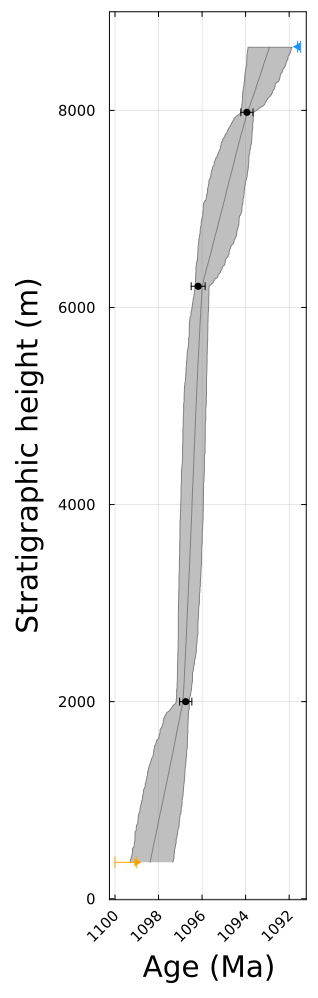

In [18]:
NSVG_SW_age_model = plot_age_model(NSVG_SW_section, NSVG_SW_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 9000), left_margin = 12Plots.mm, legend=false, guidefontsize=20)
savefig(NSVG_SW_age_model, NSVG_SW_section.Path*"_AgeDepthModel.pdf")
display(NSVG_SW_age_model)

### example posterior accumulation models

agemin: 1092.8861262405053, agemax: 1098.382665647775, halfw: 0.5, Δt: 0.5
Number of windows: 9
  0.019700 seconds (9.01 k allocations: 20.691 MiB, 41.70% gc time)


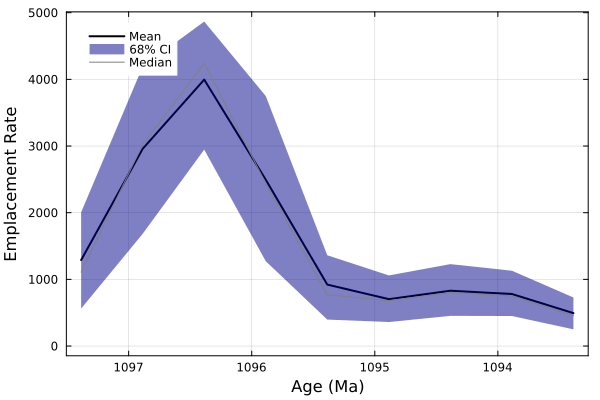

In [6]:
plot_accumulation_model(NSVG_SW_section, NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, binwidth=1, stepfrac=0.5, save_figure=false)

### example posterior age models

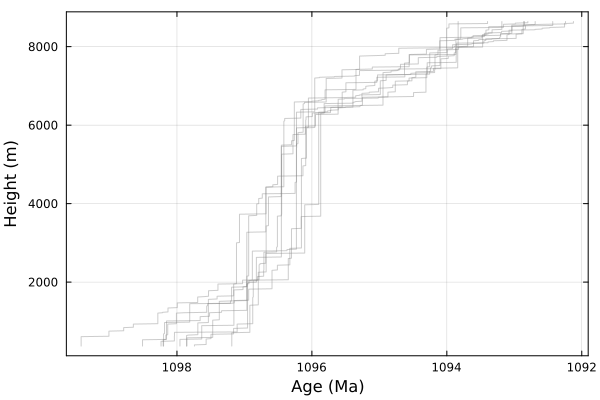

In [7]:
plot_posterior_paths(NSVG_SW_section, NSVG_SW_age_model_agedist, NSVG_SW_age_model_mdl)

## save the age models to a file

In [8]:
NSVG_SW_age_model_agedist

828×1000 Matrix{Float64}:
 1098.58  1098.66  1098.22  1098.37  …  1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1098.37     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89  …  1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
 1098.58  1098.66  1098.22  1097.89     1098.32  1098.07  1098.67  1098.91
    ⋮                                ⋱                             
 1093.59  1092.89  1093.0   1092.48     1092.3   1093.34  1093.54  1093.8
 1093.59  1092.89  1093.0   1092.48  …  1092.3   1093.34  1093.54  1093.8
 1093.59

In [10]:
# use the mdl.height as index, agedist as the data
NSVG_SW_age_models_df = DataFrame(hcat(NSVG_SW_age_model_mdl.Height, NSVG_SW_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(NSVG_SW_age_models_df, Dict(:x1 => "height"))
NSVG_SW_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,370.0,1098.58,1098.66,1098.22,1098.37,1098.43,1098.24,1098.58,1098.8,1098.93,1099.01,1098.3,1098.91,1099.06,1097.9,1097.99,1098.64,1098.57,1098.41,1097.61,1097.72,1098.81,1098.54,1097.99,1097.83,1098.35,1098.45,1098.92,1098.72,1097.82,1098.61,1098.71,1098.76,1098.42,1098.25,1097.93,1097.84,1098.46,1098.91,1098.95,1098.12,1098.71,1098.99,1098.09,1098.52,1098.47,1098.99,1098.17,1097.77,1097.8,1098.6,1097.25,1097.38,1097.56,1097.9,1098.32,1098.6,1097.47,1098.07,1097.43,1099.05,1098.41,1098.09,1098.65,1099.01,1097.74,1099.06,1098.61,1099.02,1098.7,1098.44,1097.55,1098.13,1099.11,1099.14,1099.35,1098.42,1099.03,1098.52,1098.13,1098.16,1097.64,1097.81,1098.64,1098.47,1098.16,1098.33,1098.64,1097.99,1098.83,1097.39,1098.34,1098.49,1098.86,1099.03,1098.05,1098.97,1099.09,1098.38,1099.16,⋯
2,380.0,1098.58,1098.66,1098.22,1098.37,1098.43,1098.24,1098.58,1098.8,1098.93,1099.01,1098.3,1098.91,1099.06,1097.9,1097.99,1098.64,1098.46,1098.41,1097.61,1097.72,1098.81,1098.54,1097.99,1097.83,1098.35,1098.45,1098.92,1098.72,1097.82,1098.61,1098.44,1098.76,1098.42,1098.25,1097.93,1097.84,1098.46,1098.64,1098.95,1098.12,1098.71,1098.99,1098.09,1098.52,1098.47,1098.99,1098.17,1097.77,1097.8,1098.6,1097.25,1097.38,1097.56,1097.9,1098.32,1098.6,1097.47,1098.07,1097.43,1099.05,1098.41,1098.09,1098.65,1099.01,1097.74,1099.06,1098.61,1099.02,1098.7,1098.44,1097.55,1098.13,1099.11,1099.14,1099.35,1098.42,1099.03,1098.3,1098.13,1098.16,1097.64,1097.81,1098.64,1098.47,1098.16,1098.33,1098.64,1097.99,1098.83,1097.39,1098.34,1098.49,1098.86,1099.03,1098.05,1098.97,1099.09,1098.38,1099.16,⋯
3,390.0,1098.58,1098.66,1098.22,1097.89,1098.43,1098.24,1098.58,1098.8,1098.93,1099.01,1098.3,1098.91,1099.06,1097.9,1097.99,1098.64,1098.46,1098.41,1097.61,1097.72,1098.81,1098.54,1097.8,1097.83,1098.35,1098.45,1098.92,1098.72,1097.82,1098.61,1098.44,1098.76,1098.42,1098.25,1097.93,1097.84,1098.46,1098.64,1098.95,1098.12,1098.71,1098.99,1098.09,1098.52,1098.47,1098.99,1098.17,1097.72,1097.8,1098.6,1097.25,1097.38,1097.56,1097.9,1098.32,1098.6,1097.47,1098.07,1097.43,1099.05,1098.41,1098.09,1098.65,1099.01,1097.74,1099.06,1098.61,1099.02,1098.7,1098.44,1097.55,1098.13,1099.11,1099.14,1099.35,1098.42,1099.03,1098.3,1098.13,1098.16,1097.64,1097.81,1098.64,1098.47,1098.16,1098.33,1098.64,1097.99,1098.83,1097.39,1098.34,1098.49,1098.86,1099.03,1098.05,1098.97,1099.09,1098.38,1099.16,⋯
4,400.0,1098.58,1098.66,1098.22,1097.89,1098.43,1098.24,1098.58,1098.8,1098.93,1099.01,1098.3,1098.91,1098.91,1097.9,1097.99,1098.64,1098.46,1098.41,1097.61,1097.72,1098.78,1098.54,1097.8,1097.83,1098.35,1098.45,1098.92,1098.72,1097.82,1098.61,1098.44,1098.76,1098.42,1098.25,1097.93,1097.84,1098.46,1098.64,1098.95,1098.12,1098.71,1098.99,1098.09,1098.52,1098.47,1098.99,1098.17,1097.68,1097.8,1098.6,1097.25,1097.0

In [11]:
# write the DataFrame to a csv file
CSV.write(NSVG_SW_section.Path*"_posterior_ages.csv", NSVG_SW_age_models_df)

"../../data/age_models_output/NSVG_SW_posterior_ages.csv"